# Credit Scoring - Model Development

This notebook focuses on developing and evaluating machine learning
models for predicting the probability of serious delinquency.

The prepared dataset from the preprocessing stage is used as input.

The main objective is to build a reliable baseline model, evaluate
its performance using appropriate classification metrics, compare
different algorithms, and select a final model for deployment.

## 1. Imports & Configuration

In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

TARGET = 'SeriousDlqin2yrs'
RANDOM_STATE = 42

In [2]:
X_train = pd.read_csv('data/X_train.csv')
X_valid = pd.read_csv('data/X_valid.csv')

y_train = pd.read_csv('data/y_train.csv').squeeze()
y_valid = pd.read_csv('data/y_valid.csv').squeeze()

## 2. Problem Definition

The target variable `SeriousDlqin2yrs` indicates whether a borrower
experienced a serious delinquency within the next two years.

This is a binary classification problem:

- 0 - no serious delinquency;
- 1 - serious delinquency.

The model should estimate the probability of class `1`, rather than
only returning a binary decision.

## 3. Data Validation

Before model training, the prepared datasets are checked for
structural consistency and unexpected missing or infinite values.

In [3]:
print('Missing values:')
print('Train:', X_train.isna().sum().sum())
print('Validation:', X_valid.isna().sum().sum())

print('\nInfinite values:')
print(
    'Train:',
    np.isinf(X_train.select_dtypes(include=np.number)).sum().sum()
)

print(
    'Validation:',
    np.isinf(X_valid.select_dtypes(include=np.number)).sum().sum()
)

Missing values:
Train: 0
Validation: 0

Infinite values:
Train: 0
Validation: 0


In [4]:
assert list(X_train.columns) == list(X_valid.columns)
assert len(X_train) == len(y_train)
assert len(X_valid) == len(y_valid)

print('Data validation passed.')

Data validation passed.


In [5]:
features = [
    'RevolvingUtilizationOfUnsecuredLines_log',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio_log',
    'MonthlyIncome_log',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    'HasUnknownDelinquencyHistory',
]

In [6]:
missing_features = [
    feature for feature in features
    if feature not in X_train.columns
]

assert not missing_features, (
    f'Missing features: {missing_features}'
)

print(f'Number of features: {len(features)}')

Number of features: 11


## 4. Baseline Model — Logistic Regression

In [7]:
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')
            ),
                (
                    'scaler',
                    StandardScaler()
                )
            ]),
            numeric_features
        )
    ]
)

In [8]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

In [9]:
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [10]:
baseline_pipeline.fit(
    X_train[features],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['RevolvingUtilizationOfUnsecuredLines_log','age', 'NumberOfTime30-59DaysPastDueNotWorse',..., 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents', 'HasUnknownDelinquencyHistory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the

In [11]:
y_valid_proba = baseline_pipeline.predict_proba(
    X_valid[features]
)[:, 1]

## 5. Model Evaluation

The baseline model is evaluated using metrics suitable for an imbalanced
binary classification problem.

The main metrics are ROC-AUC and PR-AUC. Additional metrics and the
confusion matrix are used to understand the model's classification
behavior.

In [12]:
roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba
)

print(f'Validation ROC-AUC: {roc_auc:.4f}')

Validation ROC-AUC: 0.8322


In [13]:
pr_auc = average_precision_score(
    y_valid,
    y_valid_proba
)

print(f'Validation PR-AUC: {pr_auc:.4f}')

Validation PR-AUC: 0.3566


In [14]:
DEFAULT_THRESHOLD = 0.5

y_valid_pred = (
    y_valid_proba >= DEFAULT_THRESHOLD
).astype(int)

In [15]:
print(
    classification_report(
        y_valid,
        y_valid_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.9427    0.9923    0.9669     19571
           1     0.5822    0.1504    0.2390      1390

    accuracy                         0.9365     20961
   macro avg     0.7624    0.5713    0.6029     20961
weighted avg     0.9188    0.9365    0.9186     20961



## 6. Confusion Matrix

The confusion matrix shows how the model's predictions are distributed
between correct and incorrect classifications.

In [16]:
cm = confusion_matrix(
    y_valid,
    y_valid_pred
)

cm

array([[19421,   150],
       [ 1181,   209]])

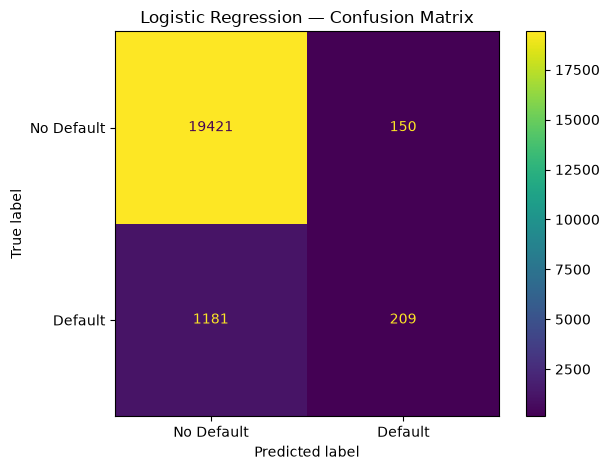

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Default', 'Default']
)

disp.plot()
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

## 7. Baseline Performance Summary

The baseline Logistic Regression model is evaluated using ROC-AUC,
PR-AUC, precision, recall, and F1-score.

ROC-AUC evaluates the model's ranking ability across all possible
classification thresholds, while PR-AUC focuses on the positive class.

In [18]:
precision = precision_score(
    y_valid,
    y_valid_pred
)

recall = recall_score(
    y_valid,
    y_valid_pred
)

f1 = f1_score(
    y_valid,
    y_valid_pred
)

baseline_metrics = pd.DataFrame({
    'Metric': [
        'ROC-AUC',
        'PR-AUC',
        'Precision',
        'Recall',
        'F1-score'
    ],
    'Value': [
        roc_auc,
        pr_auc,
        precision,
        recall,
        f1
    ]
})

baseline_metrics

,Metric,Value
0,ROC-AUC,0.832195
1,PR-AUC,0.356635
2,Precision,0.582173
3,Recall,0.150360
4,F1-score,0.238994


## 8. Threshold Analysis

The default classification threshold of 0.5 is not necessarily
optimal for credit scoring.

We evaluate several thresholds to understand the trade-off between
precision and recall and determine how the classification decision
changes with the selected threshold.

In [19]:
thresholds = np.arange(0.10, 0.61, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred = (y_valid_proba >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_valid, y_pred),
        'Recall': recall_score(y_valid, y_pred),
        'F1': f1_score(y_valid, y_pred)
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1
0,0.10,0.330824,0.505755,0.400000
1,0.15,0.413978,0.387770,0.400446
2,0.20,0.476578,0.336691,0.394604
3,0.25,0.512195,0.287050,0.367911
4,0.30,0.537994,0.254676,0.345703
5,0.35,0.547660,0.227338,0.321301
6,0.40,0.554639,0.193525,0.286933
7,0.45,0.566667,0.171223,0.262983
8,0.50,0.582173,0.150360,0.238994
9,0.55,0.573248,0.129496,0.211268


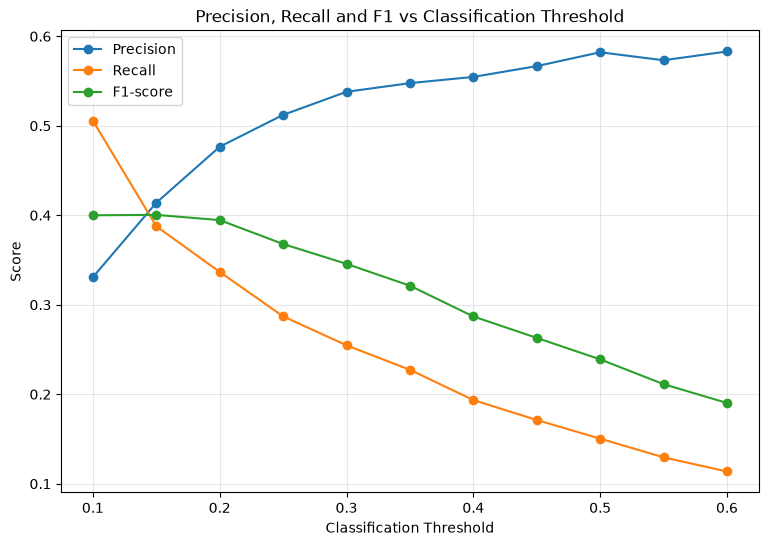

In [20]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['F1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Classification Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 9. Threshold Error Analysis

Different classification thresholds produce different numbers of
false positives and false negatives.

In credit scoring, these errors have different business implications,
so threshold selection should not be based on F1-score alone.

In [21]:
threshold_error_results = []

for threshold in thresholds:
    y_pred = (y_valid_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred
    ).ravel()

    threshold_error_results.append({
        'Threshold': threshold,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

threshold_error_results = pd.DataFrame(
    threshold_error_results
)

threshold_error_results

,Threshold,TN,FP,FN,TP
0,0.10,18149,1422,687,703
1,0.15,18808,763,851,539
2,0.20,19057,514,922,468
3,0.25,19191,380,991,399
4,0.30,19267,304,1036,354
5,0.35,19310,261,1074,316
6,0.40,19355,216,1121,269
7,0.45,19389,182,1152,238
8,0.50,19421,150,1181,209
9,0.55,19437,134,1210,180


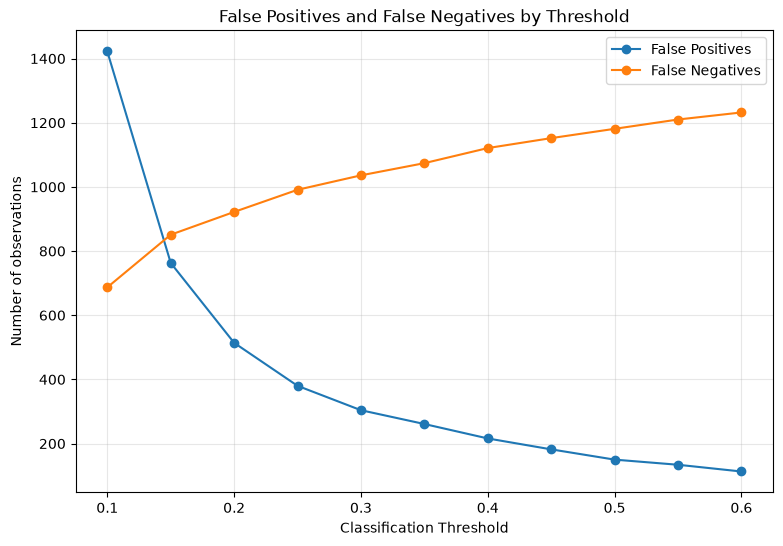

In [22]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_error_results['Threshold'],
    threshold_error_results['FP'],
    marker='o',
    label='False Positives'
)

plt.plot(
    threshold_error_results['Threshold'],
    threshold_error_results['FN'],
    marker='o',
    label='False Negatives'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Number of observations')
plt.title('False Positives and False Negatives by Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Cost-Sensitive Threshold Analysis

In credit scoring, false negatives and false positives may have
different business costs.

A false negative represents a borrower who is classified as low-risk
but subsequently experiences serious delinquency.

A false positive represents a borrower who is classified as high-risk
but does not subsequently experience serious delinquency.

We therefore evaluate thresholds using different relative costs
for these two types of errors.

In [23]:
FN_COST = 5
FP_COST = 1

cost_results = []

for threshold in thresholds:
    y_pred = (y_valid_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred
    ).ravel()

    total_cost = (
        FP_COST * fp
        + FN_COST * fn
    )

    cost_results.append({
        'Threshold': threshold,
        'FP': fp,
        'FN': fn,
        'Total Cost': total_cost
    })

cost_results = pd.DataFrame(cost_results)

cost_results

,Threshold,FP,FN,Total Cost
0,0.10,1422,687,4857
1,0.15,763,851,5018
2,0.20,514,922,5124
3,0.25,380,991,5335
4,0.30,304,1036,5484
5,0.35,261,1074,5631
6,0.40,216,1121,5821
7,0.45,182,1152,5942
8,0.50,150,1181,6055
9,0.55,134,1210,6184


In [24]:
best_threshold_row = cost_results.loc[
    cost_results['Total Cost'].idxmin()
]

best_threshold_row

Threshold        0.1
FP            1422.0
FN             687.0
Total Cost    4857.0
Name: 0, dtype: float64

## 11. Threshold Sensitivity to Error Costs

The optimal threshold depends on the relative costs assigned to false
positives and false negatives.

We evaluate several cost ratios to understand how the preferred
classification threshold changes when the cost of a false negative
increases.

In [25]:
cost_sensitivity_results = []

for fn_cost in [1, 2, 3, 5, 10]:
    for threshold in thresholds:
        y_pred = (y_valid_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_valid,
            y_pred
        ).ravel()

        total_cost = (
            fp + fn_cost * fn
        )

        cost_sensitivity_results.append({
            'FN Cost': fn_cost,
            'Threshold': threshold,
            'FP': fp,
            'FN': fn,
            'Total Cost': total_cost
        })

cost_sensitivity_results = pd.DataFrame(
    cost_sensitivity_results
)

cost_sensitivity_results

,FN Cost,Threshold,FP,FN,Total Cost
0,1,0.10,1422,687,2109
1,1,0.15,763,851,1614
2,1,0.20,514,922,1436
3,1,0.25,380,991,1371
4,1,0.30,304,1036,1340
5,1,0.35,261,1074,1335
6,1,0.40,216,1121,1337
7,1,0.45,182,1152,1334
8,1,0.50,150,1181,1331
9,1,0.55,134,1210,1344


In [26]:
best_thresholds_by_cost = (
    cost_sensitivity_results
    .loc[
        cost_sensitivity_results
        .groupby('FN Cost')['Total Cost']
        .idxmin()
    ]
    .sort_values('FN Cost')
)

best_thresholds_by_cost

,FN Cost,Threshold,FP,FN,Total Cost
8,1,0.5,150,1181,1331
13,2,0.2,514,922,2358
24,3,0.2,514,922,3280
33,5,0.1,1422,687,4857
44,10,0.1,1422,687,8292


## 12. Baseline Conclusion

Logistic Regression provides a strong and interpretable baseline for
the credit scoring problem.

The model achieves a ROC-AUC of approximately 0.83, indicating a good
ability to rank borrowers by risk.

However, the classification performance strongly depends on the
selected decision threshold. Lower thresholds increase recall of the
positive class but also increase the number of false positives.

The final threshold should therefore be selected based on the relative
business cost of false positives and false negatives rather than using
0.5 by default.

## 13. Random Forest

Random Forest is evaluated as a nonlinear alternative to Logistic
Regression.

Unlike Logistic Regression, Random Forest can capture nonlinear
relationships and interactions between features without explicitly
specifying them.

In [30]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [31]:
rf_pipeline = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        random_forest
    )
])

In [32]:
rf_pipeline.fit(
    X_train[features],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['RevolvingUtilizationOfUnsecuredLines_log','age', 'NumberOfTime30-59DaysPastDueNotWorse',..., 'NumberOfTime60-89DaysPastDueNotWorse','NumberOfDependents', 'HasUnknownDelinquencyHistory']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the

In [33]:
y_valid_proba_rf = rf_pipeline.predict_proba(
    X_valid[features]
)[:, 1]

In [37]:
rf_roc_auc = roc_auc_score(
    y_valid,
    y_valid_proba_rf
)

rf_pr_auc = average_precision_score(
    y_valid,
    y_valid_proba_rf
)

print(f'Random Forest ROC-AUC: {rf_roc_auc:.4f}')
print(f'Random Forest PR-AUC: {rf_pr_auc:.4f}')

Random Forest ROC-AUC: 0.8601
Random Forest PR-AUC: 0.3859


In [38]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'ROC-AUC': [
        roc_auc,
        rf_roc_auc
    ],
    'PR-AUC': [
        pr_auc,
        rf_pr_auc
    ]
})

model_comparison

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.832195,0.356635
1,Random Forest,0.860131,0.385867


## Random Forest - Threshold Analysis

ROC-AUC и PR-AUC оценивают качество ранжирования независимо от выбранного порога.
Теперь проверим, как изменение threshold влияет на Precision, Recall и F1.

In [39]:
thresholds = np.arange(0.10, 0.65, 0.05)

rf_threshold_results = []

for threshold in thresholds:
    y_pred_rf = (y_valid_proba_rf >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred_rf
    ).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    rf_threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

rf_threshold_results = pd.DataFrame(rf_threshold_results)

rf_threshold_results.round(4)

,Threshold,Precision,Recall,F1
0,0.10,0.0980,0.9518,0.1777
1,0.15,0.1173,0.9281,0.2082
2,0.20,0.1361,0.8971,0.2364
3,0.25,0.1567,0.8676,0.2654
4,0.30,0.1785,0.8360,0.2942
5,0.35,0.1967,0.7942,0.3152
6,0.40,0.2167,0.7590,0.3372
7,0.45,0.2384,0.7288,0.3593
8,0.50,0.2626,0.6986,0.3817
9,0.55,0.2871,0.6489,0.3981


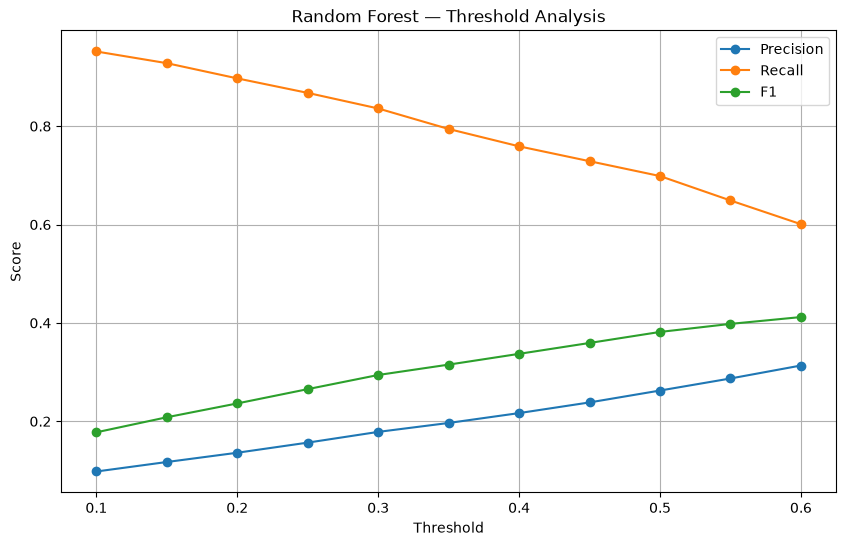

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    rf_threshold_results['Threshold'],
    rf_threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    rf_threshold_results['Threshold'],
    rf_threshold_results['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    rf_threshold_results['Threshold'],
    rf_threshold_results['F1'],
    marker='o',
    label='F1'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Random Forest — Threshold Analysis')
plt.legend()
plt.grid(True)

plt.show()

## Random Forest — Confusion Matrix by Threshold

Проверим, как изменение threshold влияет на количество
False Positive и False Negative.

In [43]:
rf_confusion_results = []

for threshold in thresholds:
    y_pred_rf = (y_valid_proba_rf >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred_rf
    ).ravel()

    rf_confusion_results.append({
        'Threshold': threshold,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

rf_confusion_results = pd.DataFrame(rf_confusion_results)

rf_confusion_results

,Threshold,TN,FP,FN,TP
0,0.10,7391,12180,67,1323
1,0.15,9862,9709,100,1290
2,0.20,11657,7914,143,1247
3,0.25,13080,6491,184,1206
4,0.30,14223,5348,228,1162
5,0.35,15061,4510,286,1104
6,0.40,15758,3813,335,1055
7,0.45,16335,3236,377,1013
8,0.50,16844,2727,419,971
9,0.55,17331,2240,488,902


## Random Forest — Feature Importance

Исследуем, какие признаки вносят наибольший вклад
в решения Random Forest.

In [44]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_pipeline.named_steps['model'].feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines_log,0.303612
2,NumberOfTime30-59DaysPastDueNotWorse,0.137756
6,NumberOfTimes90DaysLate,0.135166
3,DebtRatio_log,0.088789
1,age,0.086952
4,MonthlyIncome_log,0.071620
8,NumberOfTime60-89DaysPastDueNotWorse,0.068313
5,NumberOfOpenCreditLinesAndLoans,0.059664
7,NumberRealEstateLoansOrLines,0.025674
9,NumberOfDependents,0.017709


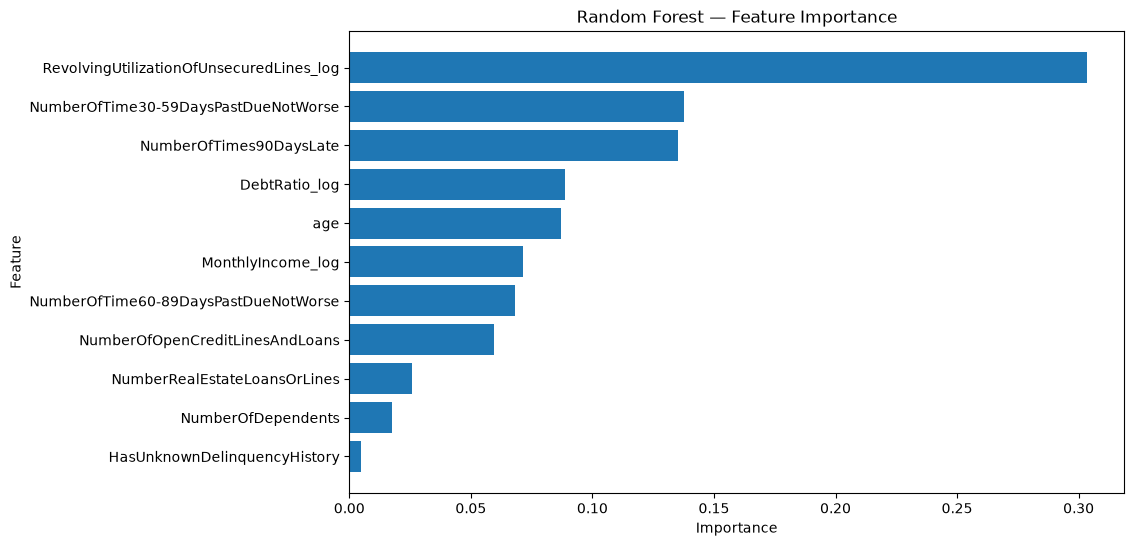

In [45]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()

plt.show()